In [7]:
import pandas as pd
import massbalancemachine as mbm
import warnings
import matplotlib.pyplot as plt
import numpy as np
from joblib import load
from cmcrameri import cm
from massbalancemachine.data_processing.glacier_utils import create_glacier_grid_RGI
from massbalancemachine.data_processing.get_topo_data import get_glacier_mask

def plotGlAttr(ds, cmap=cm.batlow):
    # Plot glacier attributes
    fig, ax = plt.subplots(2, 3, figsize=(18, 10))
    ds.masked_slope.plot(ax=ax[0, 0], cmap=cmap)
    ax[0, 0].set_title('Slope')
    ds.masked_elev.plot(ax=ax[0, 1], cmap=cmap)
    ax[0, 1].set_title('Elevation')
    ds.masked_aspect.plot(ax=ax[0, 2], cmap=cmap)
    ax[0, 2].set_title('Aspect')
    ds.masked_hug.plot(ax=ax[1, 0], cmap=cmap)
    ax[1, 0].set_title('Hugonnet')
    ds.masked_cit.plot(ax=ax[1, 1], cmap=cmap)
    ax[1, 1].set_title('Consensus ice thickness')
    ds.masked_miv.plot(ax=ax[1, 2], cmap=cmap)
    ax[1, 2].set_title('Millan v')
    plt.tight_layout()

warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
#Dumas, Bellingshausen, Calluqueo, Vernadsky
cfg = mbm.Config()
d = {'RGIId': ['RGI60-17.01632', 'RGI60-19.01992', 'RGI60-17.07250', 'RGI60-19.00730']}
df = pd.DataFrame(data=d)

In [4]:
rgi_gl = ['RGI60-17.01632', 'RGI60-19.01992', 'RGI60-17.07250', 'RGI60-19.00730']
data1 = df[df.RGIId==rgi_gl[2]]
# Definimos el directorio donde están los datos de OGGM
custom_working_dir='OGGM/'
ds, glacier_indices, gdir = get_glacier_mask(data1, custom_working_dir=custom_working_dir, cfg=cfg)

2025-09-07 22:35:32: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-09-07 22:35:32: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-09-07 22:35:32: oggm.cfg: Multiprocessing: using all available processors (N=16)
2025-09-07 22:35:33: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2025-09-07 22:35:33: oggm.cfg: Multiprocessing switched ON after user settings.
2025-09-07 22:35:33: oggm.cfg: PARAMS['continue_on_error'] changed from `False` to `True`.
2025-09-07 22:35:35: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2025-09-07 22:35:35: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers
100% of 134.8 MiB |######################| Elapsed Time: 0:00:34 Time:  0:00:3402
2025-09-07 22:36:11: oggm.workflow: Execute entity tasks [gridded_attributes] on 1 glaciers


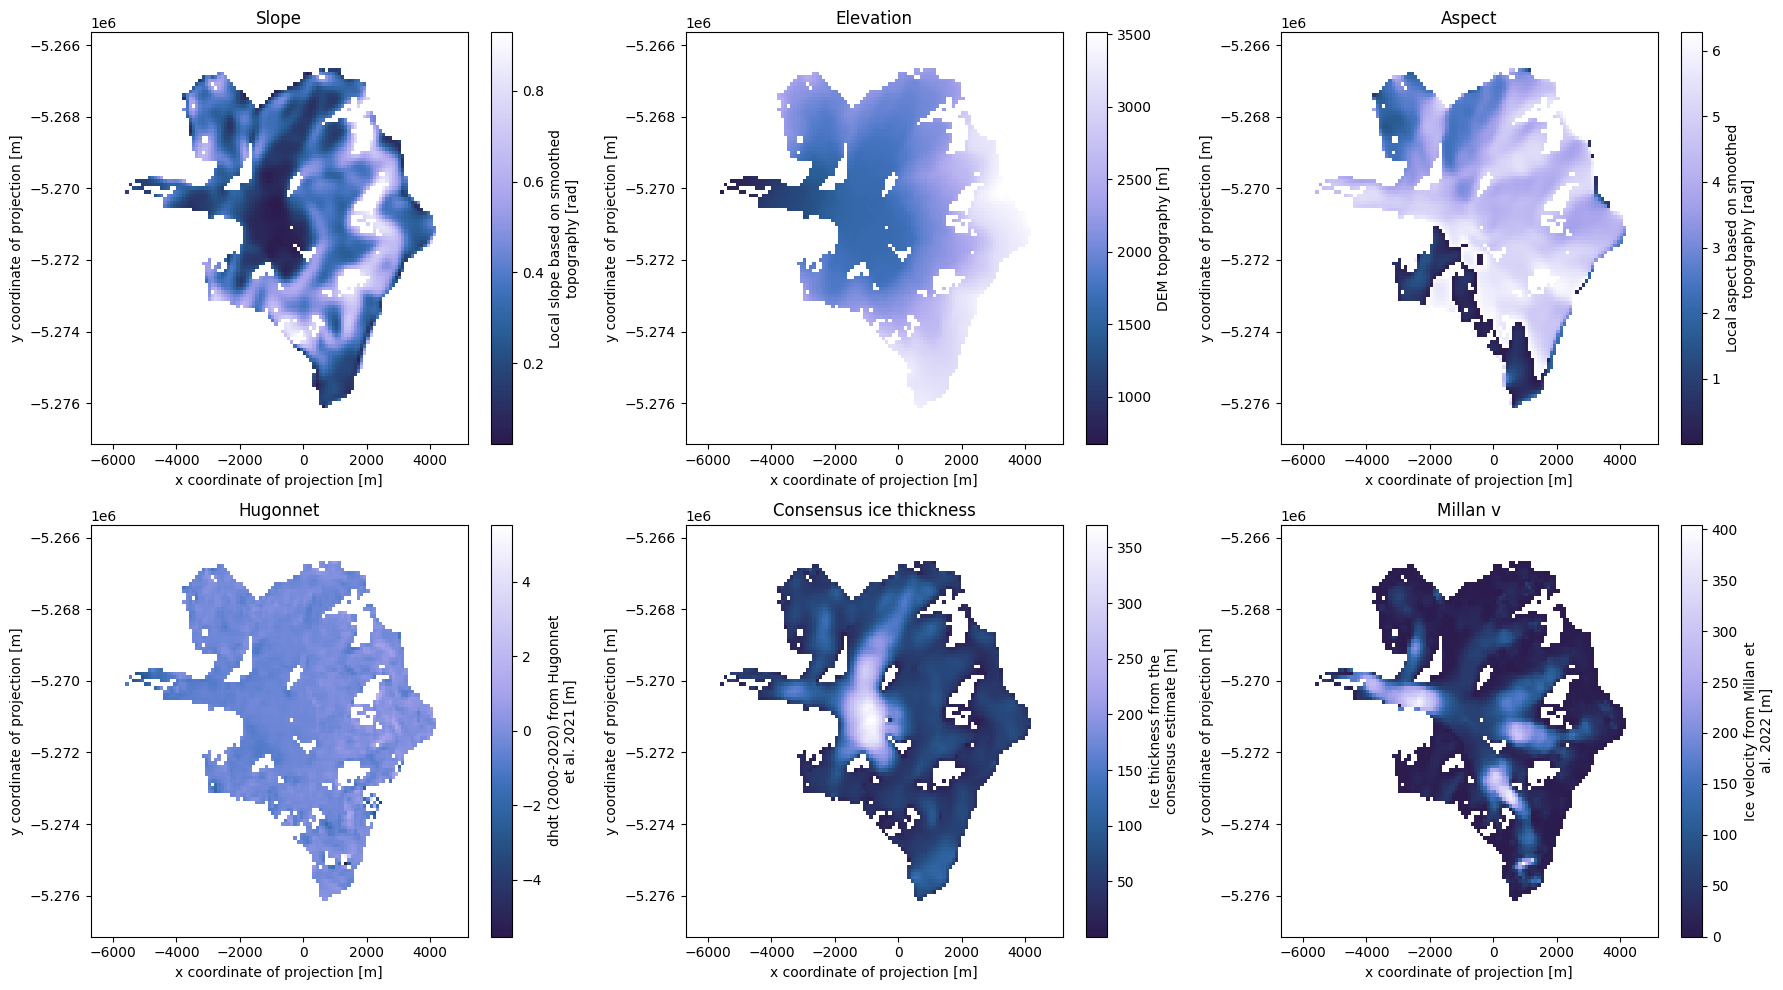

In [5]:
plotGlAttr(ds, cmap=cm.devon)

In [8]:
# Definimos el periodo, para este ejemplo solo usaremos 1 año
years = range(2016, 2017)
# Extraemos el dataframe 
df_grid = create_glacier_grid_RGI(ds, years, glacier_indices, gdir,
                                rgi_gl[2])

In [9]:
# Mantenemos variables necesarias 
var_topo = ['YEAR', 'RGIId', 'POINT_LAT', 'POINT_LON', 'aspect', 'slope',
            'POINT_ELEVATION', 'POINT_BALANCE',
            'FROM_DATE', 'TO_DATE']
data_glas =  df_grid[var_topo]
data_glas['POINT_ID'] = data_glas['RGIId']

In [12]:
# Proporcione el nombre de la columna que contiene los ID de RGI para el glacir
dataset = mbm.data_processing.Dataset(cfg=cfg, data=data_glas, region_name='cahuqueo_grid', data_path='./grid/', region_id=17)
# Especifique los archivos de datos climáticos que se corresponderán con las coordenadas de los datos de estaca
era5_climate_data = './era5land/era5_monthly_averaged_data.nc'
geopotential_data = './era5land/era5_geopotential_pressure.nc'

# Haga coincidir las características climáticas, del archivo netCDF de ERA5Land, para cada conjunto de datos de medición de estaca
dataset.get_climate_features(climate_data=era5_climate_data, geopotential_data=geopotential_data) 

In [13]:
# Especifique los nombres cortos de las variables climáticas disponibles en el conjunto de datos
vois_climate = ['t2m', 'tp', 'slhf', 'sshf', 'ssrd', 'fal', 'str']
voi_topographical = ['aspect', 'slope']
# Para cada registro, conviértalo a una resolución de tiempo mensual
dataset.convert_to_monthly(vois_climate=vois_climate, vois_topographical=voi_topographical)


In [14]:
# Visualizando 
display(dataset.data)

,YEAR,POINT_LON,POINT_LAT,POINT_BALANCE,ALTITUDE_CLIMATE,ELEVATION_DIFFERENCE,POINT_ELEVATION,RGIId,POINT_ID,ID,...,MONTHS,aspect,slope,t2m,tp,slhf,sshf,ssrd,fal,str
0,2016,-72.361086,-47.553675,0,1105.524780,1197.475220,2303.0,RGI60-17.07250,RGI60-17.07250,0,...,sep,4.523725,0.245728,270.944092,0.001915,-156770.0,-610196.0,15150511.0,0.734729,-3149844.0
1,2016,-72.361086,-47.553675,0,1105.524780,1197.475220,2303.0,RGI60-17.07250,RGI60-17.07250,0,...,oct,4.523725,0.245728,271.315674,0.002765,-883920.0,-1485764.0,21140524.0,0.691847,-3634364.0
2,2016,-72.361086,-47.553675,0,1105.524780,1197.475220,2303.0,RGI60-17.07250,RGI60-17.07250,0,...,nov,4.523725,0.245728,273.011963,0.004306,-1002948.0,-1955456.0,25046848.0,0.617576,-3289330.0
3,2016,-72.361086,-47.553675,0,1105.524780,1197.475220,2303.0,RGI60-17.07250,RGI60-17.07250,0,...,dec,4.523725,0.245728,274.481201,0.007713,-1078680.0,-1949684.0,25242596.0,0.626199,-2255334.0
4,2016,-72.361086,-47.553675,0,1105.524780,1197.475220,2303.0,RGI60-17.07250,RGI60-17.07250,0,...,jan,4.523725,0.245728,279.177979,0.002268,-2370350.0,-1967874.0,24899952.0,0.420062,-3401706.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54062,2016,-72.358411,-47.638254,0,1290.956055,2009.043945,3300.0,RGI60-17.07250,RGI60-17.07250,4158,...,may,1.768956,0.261582,272.046387,0.000188,-403862.0,-344944.0,5718338.0,0.396243,-2483648.0
54063,2016,-72.358411,-47.638254,0,1290.956055,2009.043945,3300.0,RGI60-17.07250,RGI60-17.07250,4158,...,jun,1.768956,0.261582,269.849854,0.002211,-138454.0,-176472.0,4269562.0,0.596483,-1954230.0
54064,2016,-72.358411,-47.638254,0,1290.956055,2009.043945,3300.0,RGI60-17.07250,RGI60-17.07250,4158,...,jul,1.768956,0.261582,268.604492,0.002847,-71214.0,-194866.0,4835576.0,0.710596,-1385358.0
54065,2016,-72.358411,-47.638254,0,1290.956055,2009.043945,3300.0,RGI60-17.07250,RGI60-17.07250,4158,...,aug,1.768956,0.261582,268.872803,0.008360,-82870.0,-373976.0,7719606.0,0.761186,-1665310.0


In [17]:
XGB_model = load('./models/nn_Pa/data.pkl')
data = dataset.data

UnpicklingError: unsupported persistent id encountered

In [13]:
nn = XGB_model.best_estimator_.set_params(device='cpu')

features, metadata = nn._create_features_metadata(data)

feature_columns = data.columns.difference(cfg.metaData)
feature_columns = feature_columns.drop(cfg.notMetaDataNotFeatures)
feature_columns = list(feature_columns)

bounds_features = {k:(np.min(data[k].values), np.max(data[k].values)) for k in feature_columns}
norm = mbm.data_processing.Normalizer(bounds_features)
norm_features = norm.normalize(features)

data['MB'] = nn.predict(norm_features)

##Agrupar predicciones mensuales (en un promedio) segun una coordenada
data_anual = data.groupby(['POINT_LAT', 'POINT_LON', 'ID', 'YEAR'], as_index=False)['MB'].mean()
data_anual.rename(columns={'MB': 'MB_ANUAL_PROMEDIO'}, inplace=True)
data_anual.head(15)

,POINT_LAT,POINT_LON,ID,YEAR,MB_ANUAL_PROMEDIO
0,-47.638254,-72.359743,4157,2016,-0.708225
1,-47.638254,-72.358411,4158,2016,-0.708225
2,-47.637355,-72.361074,4153,2016,-0.688392
3,-47.637355,-72.359743,4154,2016,-0.708225
4,-47.637354,-72.358412,4155,2016,-0.708225
5,-47.637354,-72.357080,4156,2016,-0.708225
6,-47.636455,-72.361074,4146,2016,-0.688392
7,-47.636455,-72.359743,4147,2016,-0.708225
8,-47.636455,-72.358412,4148,2016,-0.708225
9,-47.636455,-72.357080,4149,2016,-0.708225


In [14]:
#Extraer predicciones y moverlas al mask del glaciar
def prediction_to_mask(ds, year, data_anual):
    glacier_mask = np.where(ds['glacier_mask'].values == 0, np.nan,
                            ds['glacier_mask'].values)
    mask = glacier_mask == 1.0
    aux_data = data_anual[ data_anual['YEAR'] == year ]
    valores = aux_data['MB_ANUAL_PROMEDIO'].reset_index(drop=True)

    flat_vals = pd.Series(valores, index=np.argwhere(mask).tolist())
    nueva_matriz = glacier_mask.copy()
    idxs = np.argwhere(mask)
    for i, (row, col) in enumerate(idxs):
        nueva_matriz[row, col] = valores[i]
    return nueva_matriz

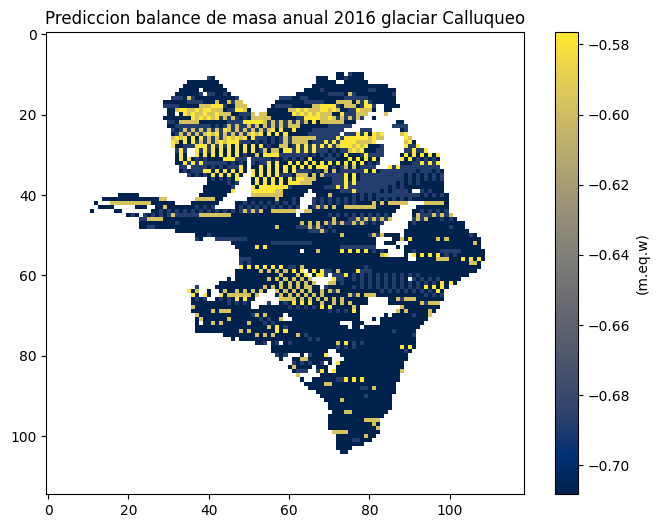

In [16]:
anio = 2016
glaciar = "Calluqueo"

fig, ax = plt.subplots(figsize=(8,6))
plt.imshow( prediction_to_mask(ds, anio, data_anual) , cmap='cividis', interpolation='nearest')
plt.colorbar(label="(m.eq.w)")
plt.title(f"Prediccion balance de masa anual {anio} glaciar {glaciar}")
plt.savefig(f"bm anual-{glaciar}-{anio}.png", dpi=300, bbox_inches="tight")
plt.show()